# ТАПСЫРМА 2: Пішіндерді талдау (контурлар мен бұрыштар)

Мақсат: суреттегі нысандардың пішінін табу және санау.

In [1]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

In [2]:
def load_gray(path):
    img = cv2.imread(path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return img, gray

In [3]:
def make_binary(gray):
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return binary

In [4]:
def find_and_draw_contours(img, binary):
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    count = 0
    for c in contours:
        if cv2.contourArea(c) > 500:
            cv2.drawContours(img, [c], -1, (0, 255, 0), 2)
            count += 1
    return count

In [5]:
def mark_corners(img, gray):
    gray = np.float32(gray)
    corners = cv2.cornerHarris(gray, 2, 3, 0.04)
    corners = cv2.dilate(corners, None)
    img[corners > 0.01 * corners.max()] = [0, 0, 255]

Үлкен нысандар саны: 1


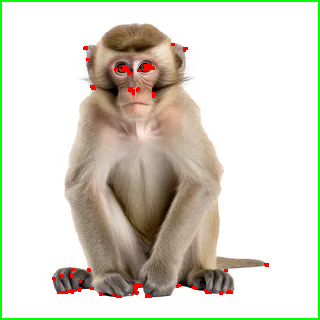

In [10]:
img, gray = load_gray('monkey.webp')

binary = make_binary(gray)
count = find_and_draw_contours(img, binary)
mark_corners(img, gray)

cv2.imwrite('out_shapes.jpg', img)
print(f'Үлкен нысандар саны: {count}')
cv2_imshow(img)